# **E-Commerce Customer Segmentation**
## *Project Checkpoint 1*
### *Dataset: Online Retail II*

## ***Introduction***

In this project, we aim to segment e-commerce customers based on their purchasing behavior.

This problem is formulated as an **unsupervised learning task (clustering)**.

For Checkpoint 1, we:
- Explore and visualize the dataset
- Perform data cleaning
- Engineer RFM features
- Build a preliminary clustering pipeline
- Evaluate clustering quality
- Interpret clusters
- Identify issues and propose improvements

## ***1. IMPORTING LIBRARIES***


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
RANDOM_STATE = 42

## ***2. Load Dataset***

In [5]:
from pathlib import Path

dataset_path = Path("data/online_retail_II.xlsx")
if not dataset_path.exists():
    dataset_path = Path("../data/online_retail_II.xlsx")

df = pd.read_excel(dataset_path)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (525461, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## ***3. Initial Data Exploration***

We inspect data types, missing values, and summary statistics.

In [6]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 38.8+ MB


In [8]:
# Check missing values
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

## ***4. Data Cleaning***

We remove:
- Missing Customer IDs
- Cancelled invoices
- Negative quantities
- Invalid price values

In [9]:
# Clean column names
df.columns = df.columns.str.strip()

# Detect important columns
price_col = "Price"
cust_col = "Customer ID"
invoice_col = "Invoice"
date_col = "InvoiceDate"
qty_col = "Quantity"

# Remove missing customers
df = df.dropna(subset=[cust_col])

# Remove cancelled invoices
df[invoice_col] = df[invoice_col].astype(str)
df = df[~df[invoice_col].str.startswith("C")]

# Remove invalid quantities and prices
df = df[(df[qty_col] > 0) & (df[price_col] > 0)]

# Convert date
df[date_col] = pd.to_datetime(df[date_col])

# Create total amount
df["TotalAmount"] = df[qty_col] * df[price_col]

print("Cleaned dataset shape:", df.shape)
df.head()

Cleaned dataset shape: (407664, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


## ***5. Feature Engineering: RFM Model***

We aggregate transaction-level data into customer-level features:

- Recency: Days since last purchase
- Frequency: Number of unique invoices
- Monetary: Total spending

In [10]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Recency
recency = df.groupby('Customer ID')['InvoiceDate'].max().reset_index()
recency['Recency'] = (snapshot_date - recency['InvoiceDate']).dt.days

# Frequency
frequency = df.groupby('Customer ID')['Invoice'].nunique().reset_index()
frequency.columns = ['Customer ID', 'Frequency']

# Monetary
monetary = df.groupby('Customer ID')['TotalAmount'].sum().reset_index()
monetary.columns = ['Customer ID', 'Monetary']

# Merge
rfm = recency[['Customer ID','Recency']] \
    .merge(frequency, on='Customer ID') \
    .merge(monetary, on='Customer ID')

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346.0,165,11,372.86
1,12347.0,3,2,1323.32
2,12348.0,74,1,222.16
3,12349.0,43,3,2671.14
4,12351.0,11,1,300.93


## ***6. Exploratory Data Analysis***

We analyze the distribution and relationships of RFM features.

Key goals:
- Identify skewness
- Detect outliers
- Understand feature relationships
- Observe customer heterogeneity

In [11]:
rfm.describe()

,Customer ID,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.000000,4312.000000
mean,15349.290353,91.171846,4.455705,2048.238236
std,1701.200176,96.860633,8.170213,8914.481280
min,12346.000000,1.000000,1.000000,2.950000
25%,13882.500000,18.000000,1.000000,307.987500
50%,15350.500000,53.000000,2.000000,706.020000
75%,16834.250000,136.000000,5.000000,1723.142500
max,18287.000000,374.000000,205.000000,349164.350000


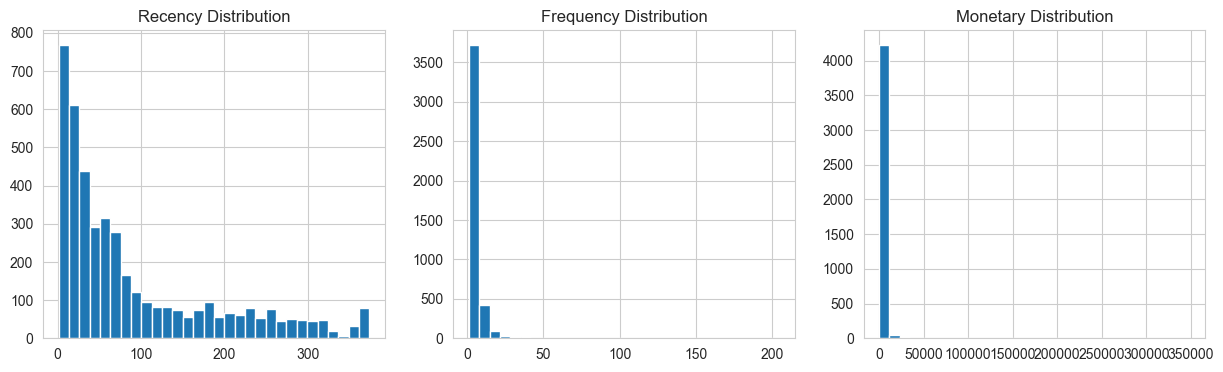

In [12]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.hist(rfm["Recency"], bins=30)
plt.title("Recency Distribution")

plt.subplot(1,3,2)
plt.hist(rfm["Frequency"], bins=30)
plt.title("Frequency Distribution")

plt.subplot(1,3,3)
plt.hist(rfm["Monetary"], bins=30)
plt.title("Monetary Distribution")

plt.show()

### Observations:
- Monetary is highly right-skewed.
- Most customers have low purchase frequency.
- Outliers exist in spending behavior.

## ***7. Correlation Matrix***

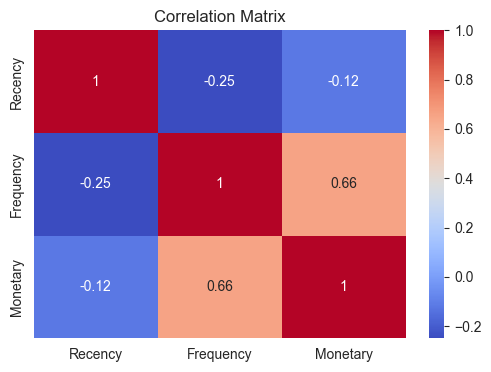

In [13]:

plt.figure(figsize=(6,4))
sns.heatmap(rfm[["Recency","Frequency","Monetary"]].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## ***8. Outlier Analysis***

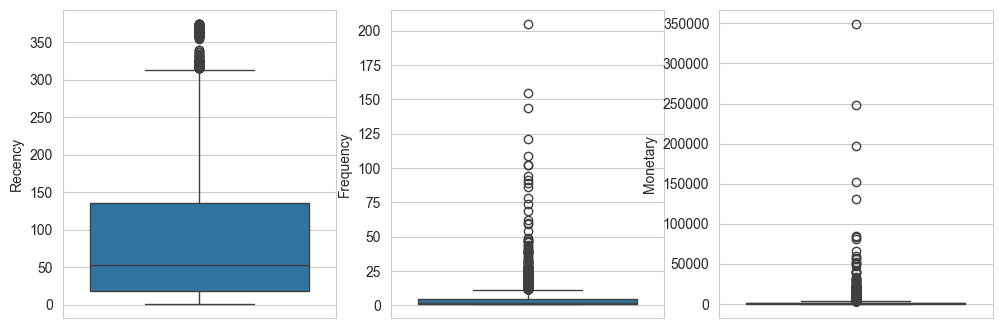

In [14]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.boxplot(y=rfm["Recency"])

plt.subplot(1,3,2)
sns.boxplot(y=rfm["Frequency"])

plt.subplot(1,3,3)
sns.boxplot(y=rfm["Monetary"])

plt.show()

## ***9. Data Transformation***

Clustering is sensitive to scale and skewness.

We:
- Apply log transformation
- Standardize features

In [15]:
rfm_log = rfm.copy()
rfm_log[['Recency','Frequency','Monetary']] = \
    np.log1p(rfm_log[['Recency','Frequency','Monetary']])

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(
    rfm_log[['Recency','Frequency','Monetary']]
)

## ***10. Determine Optimal K (Elbow Method)***

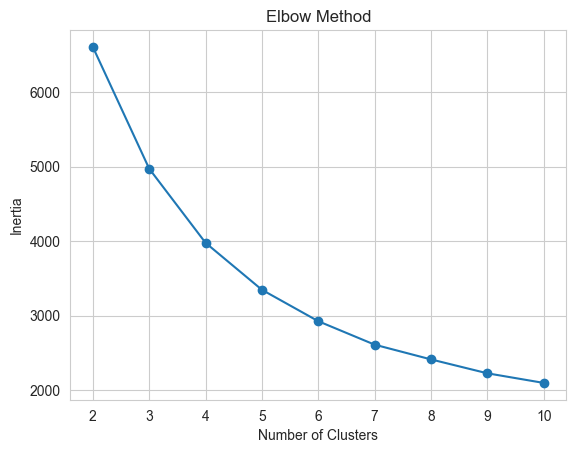

In [16]:
inertia = []
K_range = range(2,11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

## ***11. Apply K-Means Clustering***

In [17]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Customer ID,Recency,Frequency,Monetary,Cluster
0,12346.0,165,11,372.86,2
1,12347.0,3,2,1323.32,0
2,12348.0,74,1,222.16,1
3,12349.0,43,3,2671.14,2
4,12351.0,11,1,300.93,0


## ***12. Clustering Evaluation***

In [18]:
sil_score = silhouette_score(rfm_scaled, rfm["Cluster"])
print("Silhouette Score:", sil_score)

Silhouette Score: 0.3331057440143532


Silhouette score interpretation:
- Closer to 1 → well separated clusters
- Around 0.3–0.5 → moderate separation
- Near 0 → overlapping clusters

## ***13. Cluster Size Distribution***

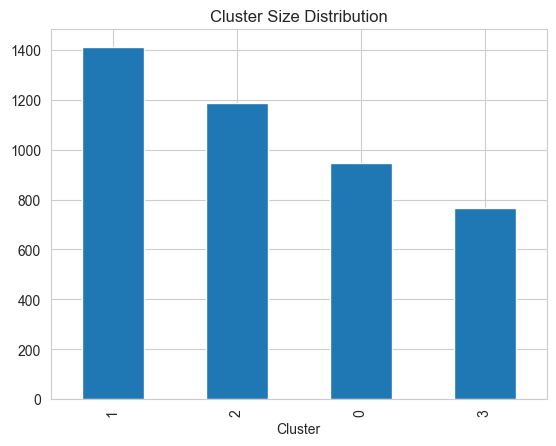

In [19]:
rfm["Cluster"].value_counts().plot(kind="bar")
plt.title("Cluster Size Distribution")
plt.show()

## ***14. Cluster Interpretation***

In [20]:
cluster_summary = rfm.groupby("Cluster")[["Recency","Frequency","Monetary"]].mean()
cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,22.250794,2.121693,576.945207
1,185.938385,1.288244,302.142020
2,83.191919,4.122054,1775.009363
3,13.988266,13.679270,7498.636764


### Preliminary Interpretation:

Cluster with:
- Low Recency, High Frequency, High Monetary → Champions
- High Recency, Low Frequency → At Risk
- Low Monetary, Low Frequency → Low Value
- Moderate across features → Occasional Buyers

## ***15. PCA Visualization of Clusters***

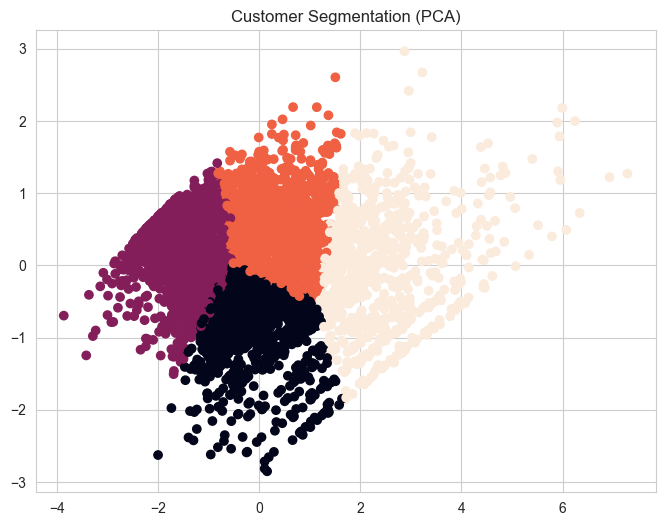

In [21]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(rfm_scaled)

plt.figure(figsize=(8,6))
plt.scatter(pca_data[:,0], pca_data[:,1], c=rfm["Cluster"])
plt.title("Customer Segmentation (PCA)")
plt.show()

## ***16. Issues Identified***

- Outliers influence centroids.
- K-Means assumes spherical clusters.
- Optimal K selection is heuristic.
- Silhouette score indicates moderate separation.
- RFM may not capture full behavioral complexity.

These issues suggest the model can be improved.

## ***17. Future Plan (Checkpoint 2)***


- Compare with Hierarchical clustering
- Try DBSCAN
- Improve outlier handling
- Engineer additional features
- Explore clustering + classification